In [1]:
import toml
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

In [2]:
# ANALYSIS SPECIFIC DIRECTORIES
ana_directory = "../../1muNp0pi_Nge1_uncontained"
data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'


Processing systematics for sample: mc
--Systematic(statistical, None)--
	Fractional uncertainty: 0.38%
--Systematic(stats, Stat.)--
	Fractional uncertainty: 0.38%
--Systematic(MC_total, All Systematics (No G4))--
	Fractional uncertainty: 0.38%

Processing systematics for sample: mc_nonmatched

Processing systematics for sample: onbeam

Processing systematics for sample: offbeam
Setting weight for mc to 3.03e-02
Setting weight for mc_nonmatched to 3.03e-02
Setting weight for onbeam to 1.00e+00
Setting weight for offbeam to 9.53e-02


/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/vertex_z/../../../spectra1d.py:706: RuntimeWarning: invalid value encountered in divide
  f"Fractional - Min: {(uncertainty / y_pred).min():.2%}, Max: {(uncertainty / y_pred).max():.2%}")
/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/vertex_z/../../../spectra1d.py:706: RuntimeWarning: invalid value encountered in divide
  f"Fractional - Min: {(uncertainty / y_pred).min():.2%}, Max: {(uncertainty / y_pred).max():.2%}")


Fractional - Min: nan%, Max: nan%
Fractional - Min: nan%, Max: nan%


/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/vertex_z/../../../spectra1d.py:706: RuntimeWarning: invalid value encountered in divide
  f"Fractional - Min: {(uncertainty / y_pred).min():.2%}, Max: {(uncertainty / y_pred).max():.2%}")


Fractional - Min: nan%, Max: nan%


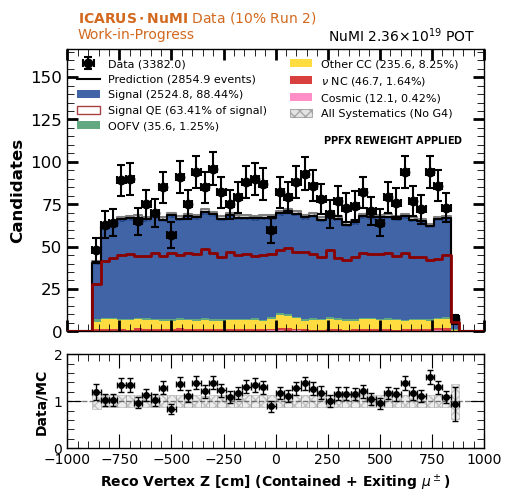

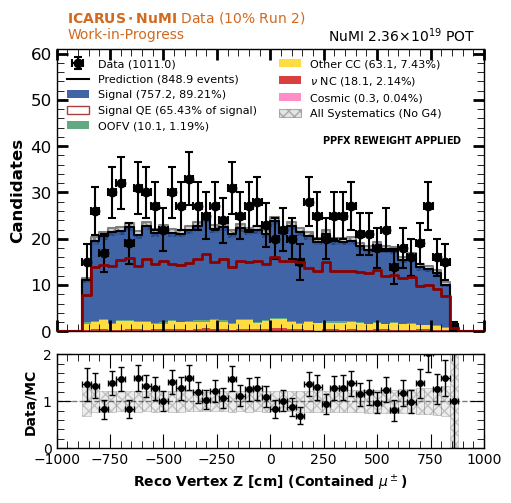

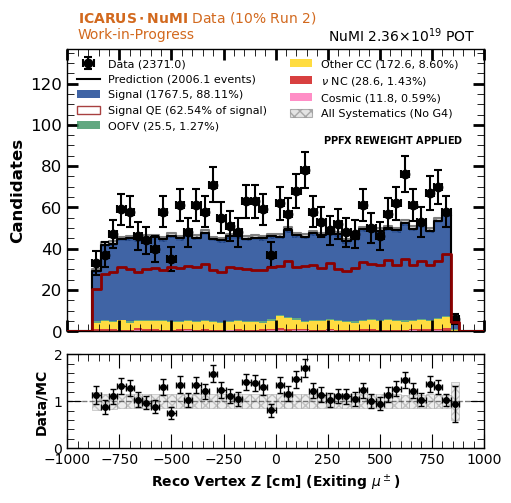

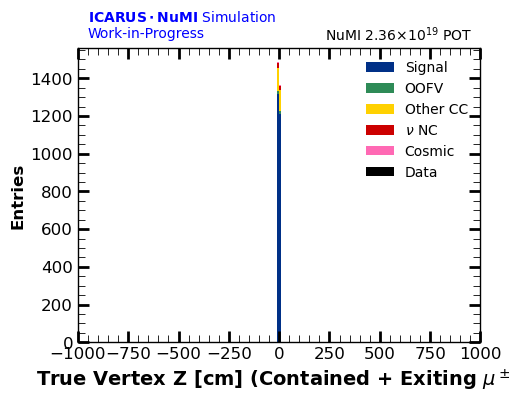

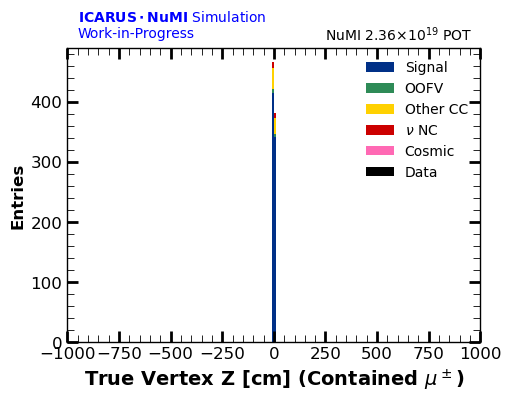

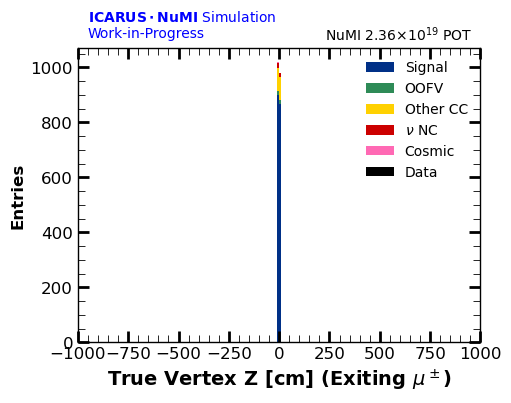

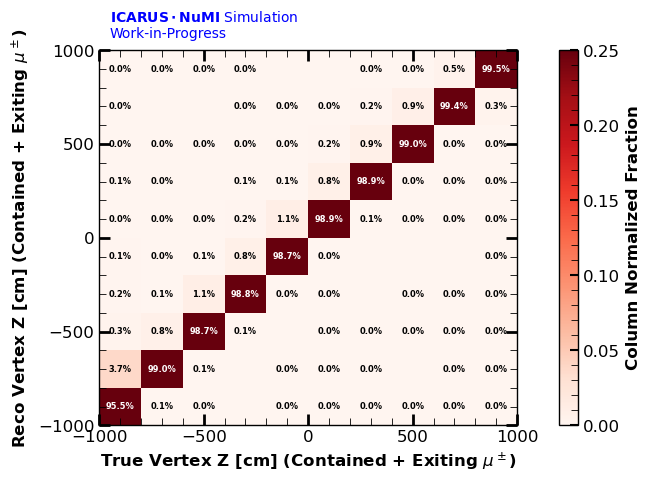

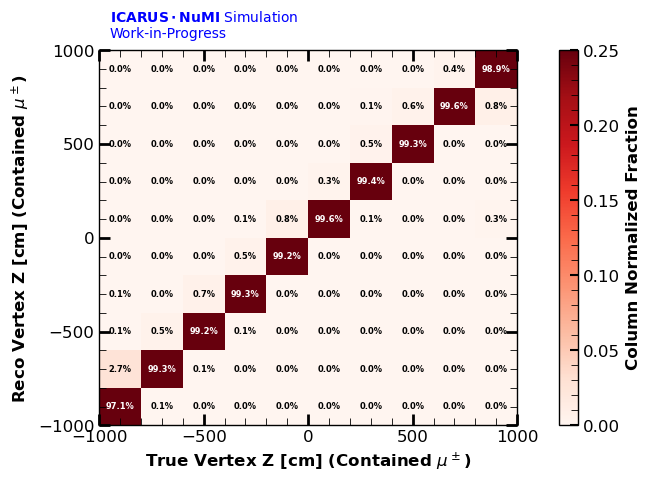

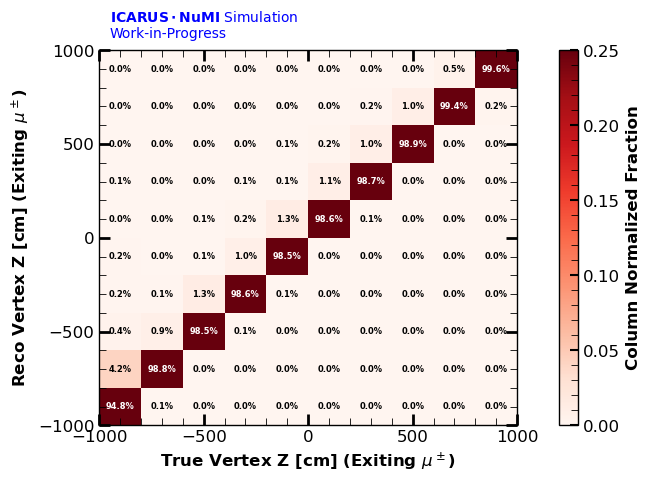

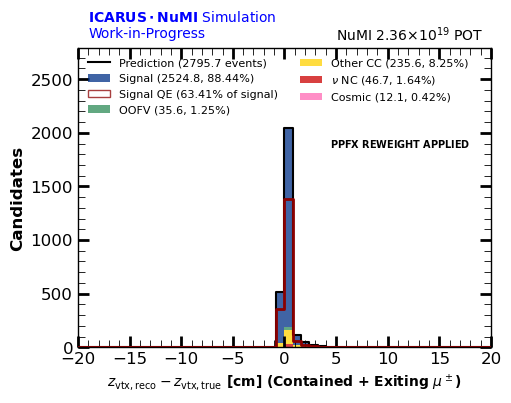

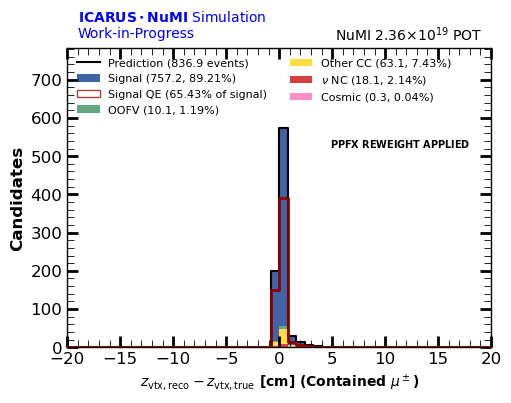

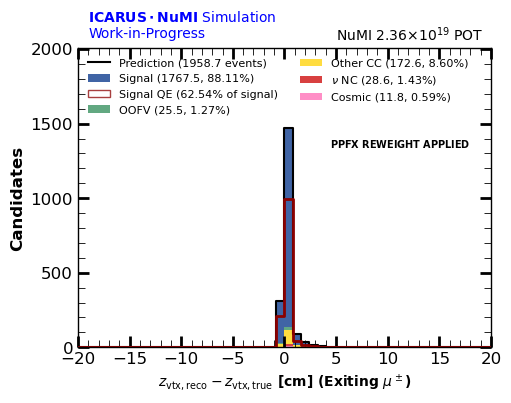

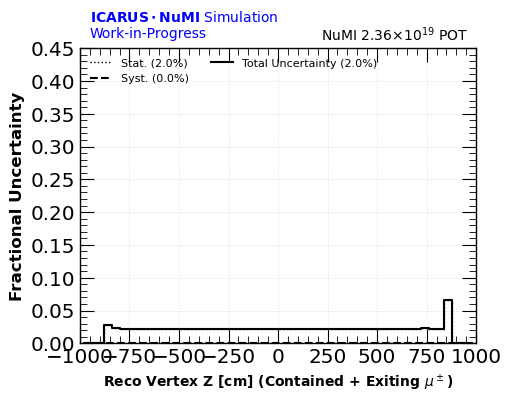

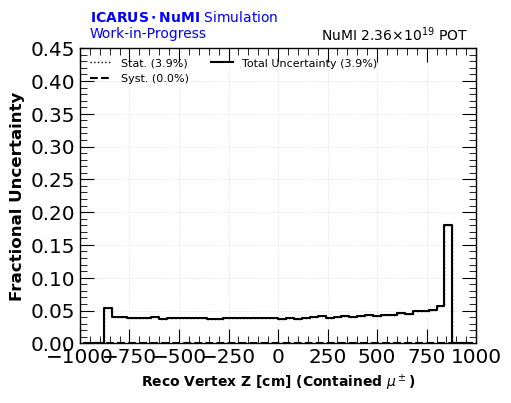

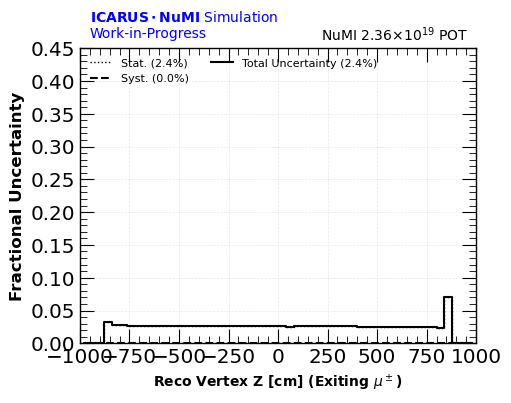

In [3]:
analysis = Analysis(ana_directory + '/vertex_z/vertex_z.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# File and tree
fpath = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam_withPCA.root'

with uproot.open(fpath) as f:
    tree = f['events/full/selected']
    reco_vtx_z    = tree['reco_vertex_z'].array(library='np')
    true_vtx_z    = tree['true_vertex_z'].array(library='np')
    true_category = tree['true_category'].array(library='np')

# Signal categories
signal_mask = np.isin(true_category, [0, 1, 3, 4])

# Valid kinematics mask
valid_mask = (
    np.isfinite(true_vtx_z) &
    np.isfinite(reco_vtx_z)
)

# Compute absolute residual
abs_residual = reco_vtx_z - true_vtx_z

# Combined mask
combined_mask = signal_mask & valid_mask

# Binning
x_bins = np.linspace(-1000, 1000, 41)
y_bins = np.linspace(-20, 20, 51)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

h, xedges, yedges = np.histogram2d(
    true_vtx_z[combined_mask],
    abs_residual[combined_mask],
    bins=[x_bins, y_bins]
)

im = ax.imshow(
    h.T,
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    origin='lower',
    norm=mcolors.LogNorm(vmin=1, vmax=h.max()),
    cmap='magma'
)

ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_xlabel('True Vertex Z [cm]', fontsize=12, fontweight='bold')
ax.set_ylabel(r'$z_{\mathrm{vtx,reco}} - z_{\mathrm{vtx,true}}$ [cm]', fontsize=12, fontweight='bold')
ax.set_title('Vertex Z Resolution', fontsize=13, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=11, size=6, width=1.5)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Signal Events', fontsize=11, fontweight='bold')
cbar.ax.tick_params(labelsize=10)

plt.savefig('pdf/vertex_z_resolution_vs_true.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Vertex Z cross-section uncertainties
analysis = Analysis(ana_directory + '/vertex_z/vertex_z_xSecUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Vertex Z cross-section uncertainties expanded
analysis = Analysis(ana_directory + '/vertex_z/vertex_z_xSecUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Vertex Z flux uncertainties
analysis = Analysis(ana_directory + '/vertex_z/vertex_z_FluxUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Vertex Z flux uncertainties expanded
analysis = Analysis(ana_directory + '/vertex_z/vertex_z_FluxUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Vertex Z detector uncertainties
analysis = Analysis(ana_directory + '/vertex_z/vertex_z_DetectorUncertainty.toml', data_file)
analysis.run(close_figs=False)